# `RandomResizedCrop(scale=...)` 는 **면적** 비율이다

DINO의 multi-crop 설정:

| crop | 출력 해상도 | `scale` |
|---|---|---|
| global × 2 | 224 | $(0.4,\ 1.0)$ |
| local × 8 | 96 | $(0.05,\ 0.4)$ |

`scale` 은 **원본 면적 대비 비율** $s = \dfrac{h_c w_c}{H W}$ 이지 한 변의 길이 비율이 아니다.
길이 비율은 제곱근이므로

$$
\frac{\text{crop 한 변}}{\text{원본 한 변}} \;\approx\; \sqrt{s}
$$

이고, 따라서 $s = 0.4$ 는 "한 변의 40%"가 아니라 **한 변의 약 63%** 다.

필요 패키지: torch, torchvision, plotly, kaleido, numpy

In [1]:
# 필요 패키지: torch, torchvision, plotly, kaleido, numpy
import os
import math
import numpy as np
import torch
from torchvision.transforms import RandomResizedCrop
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
torch.manual_seed(0)
np.random.seed(0)
print("HERE =", HERE)

HERE = /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/5910cf71-1a62-4b36-bee0-cf47e100857f


## 1. 면적비 → 변 길이비 (직관 교정)

정사각 원본 $480 \times 480$ 기준으로 각 `scale` 값이 실제로 몇 픽셀짜리 영역인지 본다.

In [2]:
H = W = 480
print(f"{'area ratio s':>12} | {'side ratio √s':>13} | {'crop 변(px)':>11} | 의미")
print("-" * 68)
for s, note in [(0.05, "local 하한"), (0.10, "local 전형"), (0.40, "local 상한 = global 하한"),
                (1.00, "global 상한(원본 전체)")]:
    side = math.sqrt(s)
    print(f"{s:>12.2f} | {side:>13.3f} | {side * 480:>11.1f} | {note}")

area ratio s | side ratio √s |  crop 변(px) | 의미
--------------------------------------------------------------------
        0.05 |         0.224 |       107.3 | local 하한
        0.10 |         0.316 |       151.8 | local 전형
        0.40 |         0.632 |       303.6 | local 상한 = global 하한
        1.00 |         1.000 |       480.0 | global 상한(원본 전체)


## 2. `get_params` 로 실제 샘플링해서 확인

torchvision의 절차 (`RandomResizedCrop.get_params`):

1. $s \sim \mathcal{U}(s_{\min}, s_{\max})$ 를 뽑아 목표 면적 $A_t = s \cdot HW$
2. 종횡비 $r$ 을 **로그 균등**으로: $\log r \sim \mathcal{U}(\log \tfrac34, \log \tfrac43)$
3. $w = \operatorname{round}(\sqrt{A_t\, r}),\quad h = \operatorname{round}(\sqrt{A_t / r})$
4. $w \le W$ 이고 $h \le H$ 면 위치 $(i, j)$ 를 균등 랜덤으로 뽑고 반환
5. 10회 실패하면 **중앙 crop fallback** (정사각 원본이면 이미지 전체 → 면적비 $1.0$)

In [3]:
img = torch.zeros(3, H, W)  # 더미 이미지 (get_params 는 크기만 본다)
N = 20000

def sample(scale, n=N):
    out = np.empty((n, 3))  # area_ratio, aspect, side_ratio
    for k in range(n):
        i, j, h, w = RandomResizedCrop.get_params(img, scale=list(scale), ratio=[3 / 4, 4 / 3])
        out[k] = (h * w / (H * W), w / h, math.sqrt(h * w / (H * W)))
    return out

g = sample((0.4, 1.0))
l = sample((0.05, 0.4))
for name, a, lo, hi in [("global (0.4,1.0)", g, 0.4, 1.0), ("local  (0.05,0.4)", l, 0.05, 0.4)]:
    print(f"{name}: area min={a[:,0].min():.4f} max={a[:,0].max():.4f} "
          f"mean={a[:,0].mean():.4f} (구간 중앙={(lo+hi)/2:.4f})")

global (0.4,1.0): area min=0.3990 max=0.9979 mean=0.6415 (구간 중앙=0.7000)
local  (0.05,0.4): area min=0.0497 max=0.4008 mean=0.2258 (구간 중앙=0.2250)


In [4]:
# 경계가 정확히 0.4 인가? — 정수 픽셀 반올림 때문에 미세하게 넘나든다
print("겹치는 면적비 구간:", (max(0.05, 0.4), min(0.4, 1.0)), "→ 폭 0 (한 점에서만 접함)")
print(f"local max - global min = {l[:,0].max() - g[:,0].min():+.5f}  (반올림 오차 수준)")
print("local 면적 ≤ global 면적 (엄밀)  :", bool(l[:, 0].max() <= g[:, 0].min()))
print("local 면적 ≤ global 면적 (tol 1e-2):", bool(l[:, 0].max() <= g[:, 0].min() + 1e-2))

겹치는 면적비 구간: (0.4, 0.4) → 폭 0 (한 점에서만 접함)
local max - global min = +0.00179  (반올림 오차 수준)
local 면적 ≤ global 면적 (엄밀)  : False
local 면적 ≤ global 면적 (tol 1e-2): True


**주의**: 보장되는 건 *면적의 대소*뿐이다. crop **위치**는 독립적으로 뽑히므로
local crop이 global crop 안에 들어간다는 보장은 없다 — 두 crop이 전혀 겹치지 않을 수도 있다.
DINO의 "local-to-global" 학습이 성립하는 건 기하학적 포함 관계 때문이 아니라,
같은 이미지에서 나온 view들이므로 **통계적으로** 겹칠 확률이 높기 때문이다.

In [5]:
# 위치까지 고려해 IoU 를 재본다 (global 1개 vs local 1개)
def sample_boxes(scale, n):
    b = np.empty((n, 4))  # i, j, h, w
    for k in range(n):
        b[k] = RandomResizedCrop.get_params(img, scale=list(scale), ratio=[3 / 4, 4 / 3])
    return b

gb, lb = sample_boxes((0.4, 1.0), 5000), sample_boxes((0.05, 0.4), 5000)
i1, j1, h1, w1 = gb.T
i2, j2, h2, w2 = lb.T
ih = np.maximum(0, np.minimum(i1 + h1, i2 + h2) - np.maximum(i1, i2))
iw = np.maximum(0, np.minimum(j1 + w1, j2 + w2) - np.maximum(j1, j2))
inter = ih * iw
contained = inter / (h2 * w2)          # local 이 global 에 포함된 비율
print(f"local 이 global 에 완전히 포함될 확률: {np.mean(contained > 0.999):.3f}")
print(f"전혀 겹치지 않을 확률              : {np.mean(inter == 0):.3f}")
print(f"평균 포함 비율                     : {contained.mean():.3f}")

local 이 global 에 완전히 포함될 확률: 0.397
전혀 겹치지 않을 확률              : 0.003
평균 포함 비율                     : 0.857


## 3. 종횡비는 로그 균등

$\log r \sim \mathcal U(\log 0.75,\ \log 1.333)$ 이므로 $r$ 자체의 분포는 왼쪽으로 살짝 치우친다.
`scale` 이 면적이므로 종횡비를 어떻게 뽑든 **면적은 그대로 유지**된다 — 두 파라미터가 직교한다.

In [6]:
print(f"aspect r: min={g[:,1].min():.3f} max={g[:,1].max():.3f} "
      f"median={np.median(g[:,1]):.3f} (기대 median = √(3/4·4/3)=1.000)")
print(f"log r 균등성 확인: std(log r)={np.std(np.log(g[:,1])):.4f} "
      f"vs 이론 {(math.log(4/3)-math.log(3/4))/math.sqrt(12):.4f}")

aspect r: min=0.748 max=1.336 median=1.000 (기대 median = √(3/4·4/3)=1.000)
log r 균등성 확인: std(log r)=0.1549 vs 이론 0.1661


## 4. 최종 resize → 픽셀 밀도가 다르다

crop 은 마지막에 global은 $224^2$, local은 $96^2$ 로 리사이즈된다.
같은 면적비 $s=0.4$ 짜리 영역이라도

$$
\text{원본 픽셀 / 출력 픽셀} \;=\; \frac{\sqrt{s\,HW}}{\text{out}}
$$

이므로 local 은 global 보다 항상 $224/96 \approx 2.33$ 배 **거칠게** 샘플링된다.
→ local view는 "작은 영역"일 뿐 아니라 "해상도가 낮은 영역"이다.

In [7]:
for s in (0.05, 0.1, 0.4, 1.0):
    src = math.sqrt(s * H * W)
    print(f"s={s:>4}: 원본 crop 변 {src:6.1f}px → global 224 이면 {src/224:5.2f} px/px,"
          f"  local 96 이면 {src/96:5.2f} px/px")
print(f"\n동일 s 에서 밀도 비 = 224/96 = {224/96:.3f} (항상 일정)")

s=0.05: 원본 crop 변  107.3px → global 224 이면  0.48 px/px,  local 96 이면  1.12 px/px
s= 0.1: 원본 crop 변  151.8px → global 224 이면  0.68 px/px,  local 96 이면  1.58 px/px
s= 0.4: 원본 crop 변  303.6px → global 224 이면  1.36 px/px,  local 96 이면  3.16 px/px
s= 1.0: 원본 crop 변  480.0px → global 224 이면  2.14 px/px,  local 96 이면  5.00 px/px

동일 s 에서 밀도 비 = 224/96 = 2.333 (항상 일정)


## 5. 시각화

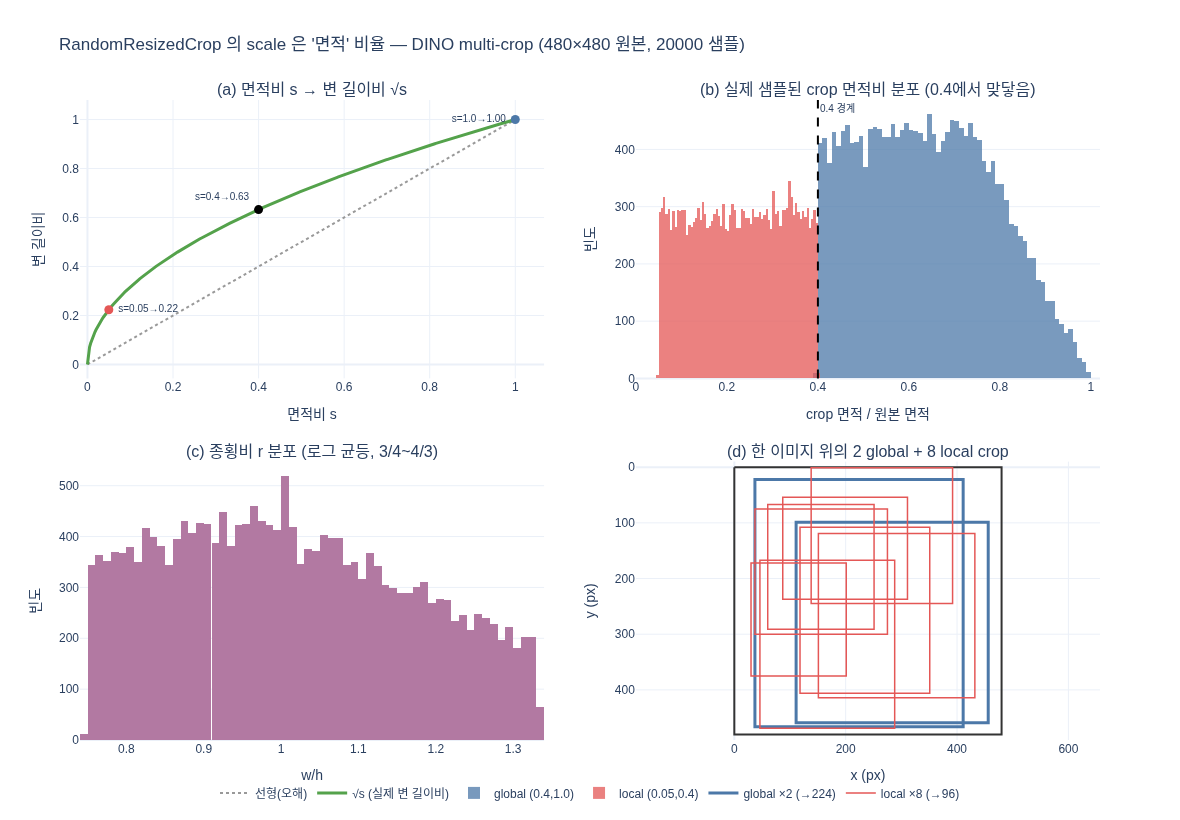

saved: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/5910cf71-1a62-4b36-bee0-cf47e100857f/expy.png


In [8]:
C_G, C_L = "#4C78A8", "#E45756"

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "(a) 면적비 s → 변 길이비 √s",
        "(b) 실제 샘플된 crop 면적비 분포 (0.4에서 맞닿음)",
        "(c) 종횡비 r 분포 (로그 균등, 3/4~4/3)",
        "(d) 한 이미지 위의 2 global + 8 local crop",
    ),
    vertical_spacing=0.13, horizontal_spacing=0.09,
)

# (a) s vs sqrt(s)
xs = np.linspace(0, 1, 400)
fig.add_trace(go.Scatter(x=xs, y=xs, name="선형(오해)", mode="lines",
                         line=dict(color="#999", dash="dot")), row=1, col=1)
fig.add_trace(go.Scatter(x=xs, y=np.sqrt(xs), name="√s (실제 변 길이비)", mode="lines",
                         line=dict(color="#54A24B", width=3)), row=1, col=1)
for s, c, pos in [(0.05, C_L, "middle right"), (0.4, "#000", "top left"),
                  (1.0, C_G, "middle left")]:
    fig.add_trace(go.Scatter(x=[s], y=[math.sqrt(s)], mode="markers+text",
                             text=[f" s={s}→{math.sqrt(s):.2f} "], textposition=pos,
                             textfont=dict(size=10), marker=dict(color=c, size=9),
                             showlegend=False), row=1, col=1)

# (b) area histograms
fig.add_trace(go.Histogram(x=g[:, 0], nbinsx=80, name="global (0.4,1.0)",
                           marker_color=C_G, opacity=0.75), row=1, col=2)
fig.add_trace(go.Histogram(x=l[:, 0], nbinsx=80, name="local (0.05,0.4)",
                           marker_color=C_L, opacity=0.75), row=1, col=2)
fig.add_vline(x=0.4, line=dict(color="black", dash="dash", width=2),
              annotation_text="0.4 경계", annotation_font_size=10, row=1, col=2)

# (c) aspect ratio
fig.add_trace(go.Histogram(x=g[:, 1], nbinsx=60, name="aspect r",
                           marker_color="#B279A2", showlegend=False), row=2, col=1)

# (d) crop boxes
fig.add_trace(go.Scatter(x=[0, W, W, 0, 0], y=[0, 0, H, H, 0], mode="lines",
                         line=dict(color="#333", width=2), name="원본 480×480",
                         showlegend=False), row=2, col=2)
torch.manual_seed(7)
for k in range(2):
    i, j, h, w = RandomResizedCrop.get_params(img, scale=[0.4, 1.0], ratio=[3 / 4, 4 / 3])
    fig.add_shape(type="rect", x0=j, y0=i, x1=j + w, y1=i + h,
                  line=dict(color=C_G, width=3), row=2, col=2)
for k in range(8):
    i, j, h, w = RandomResizedCrop.get_params(img, scale=[0.05, 0.4], ratio=[3 / 4, 4 / 3])
    fig.add_shape(type="rect", x0=j, y0=i, x1=j + w, y1=i + h,
                  line=dict(color=C_L, width=1.5), row=2, col=2)
fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines", line=dict(color=C_G, width=3),
                         name="global ×2 (→224)"), row=2, col=2)
fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines", line=dict(color=C_L, width=1.5),
                         name="local ×8 (→96)"), row=2, col=2)

fig.update_xaxes(title_text="면적비 s", row=1, col=1)
fig.update_yaxes(title_text="변 길이비", row=1, col=1)
fig.update_xaxes(title_text="crop 면적 / 원본 면적", row=1, col=2)
fig.update_yaxes(title_text="빈도", row=1, col=2)
fig.update_xaxes(title_text="w/h", row=2, col=1)
fig.update_yaxes(title_text="빈도", row=2, col=1)
fig.update_xaxes(title_text="crop 면적 / 원본 면적", range=[0, 1.02], row=1, col=2)
fig.update_xaxes(title_text="x (px)", range=[-10, 490], row=2, col=2)
# 주의: 2×2 subplot 에서 row2·col2 의 x축은 "x4" 다 ("x2" 는 row1·col2 → 엉뚱한 패널이 찌그러진다)
fig.update_yaxes(title_text="y (px)", range=[490, -10], scaleanchor="x4", row=2, col=2)
fig.update_layout(
    title="RandomResizedCrop 의 scale 은 '면적' 비율 — DINO multi-crop (480×480 원본, 20000 샘플)",
    height=820, width=1180, barmode="overlay", template="plotly_white",
    legend=dict(orientation="h", y=-0.06, x=0.5, xanchor="center"),
    font=dict(size=12),
)

_show(fig)
out_png = os.path.join(HERE, "expy.png")
fig.write_image(out_png, scale=2)
print("saved:", out_png)